In [95]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Q2 - Size of the earrings

Given:
- focal length f = 8 mm
- pixel size = 2.2 um x 2.2 um
- distance from lens to imaging plane = 720 mm

image shape: (1024, 1024, 3)


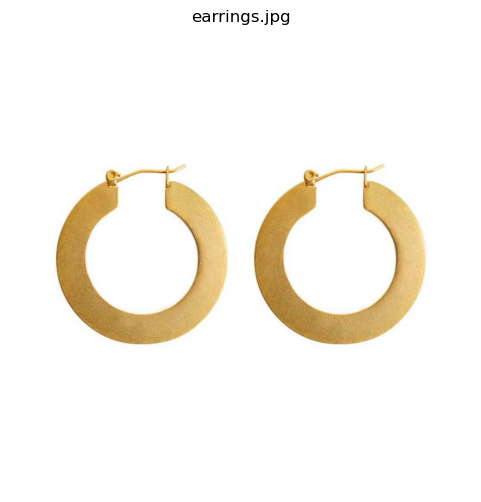

In [96]:
img = cv2.imread('earrings.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print('image shape:', img.shape)
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title('earrings.jpg')
plt.axis('off')
plt.show()

### Measure earring sizes in pixels

In [97]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
earring_contours = [c for c in contours if cv2.contourArea(c) > 500]
print(f'found {len(earring_contours)} earring contours')

found 2 earring contours


Earring 1:
  bounding box: 358 x 394 pixels
  enclosing circle diameter: 403.3 pixels

Earring 2:
  bounding box: 365 x 394 pixels
  enclosing circle diameter: 403.0 pixels



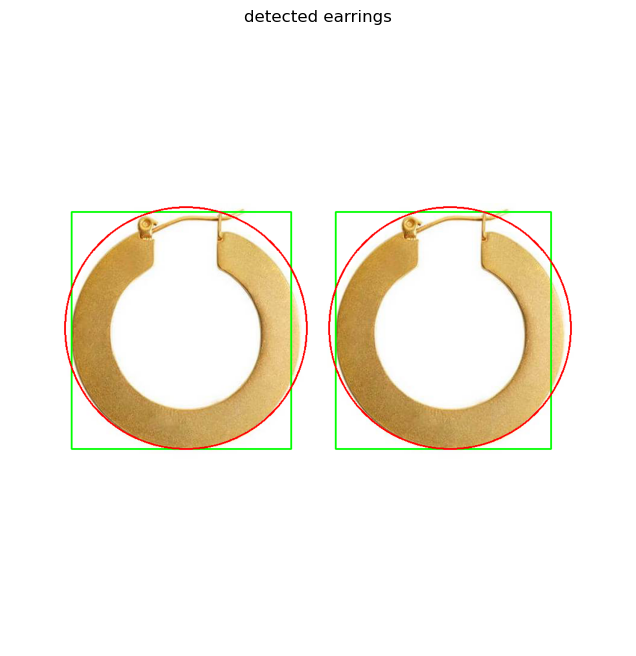

In [98]:
vis = img_rgb.copy()
for i, cnt in enumerate(earring_contours):
    x, y, w, h = cv2.boundingRect(cnt)
    (cx, cy), radius = cv2.minEnclosingCircle(cnt)
    cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.circle(vis, (int(cx), int(cy)), int(radius), (255, 0, 0), 2)
    print(f'Earring {i+1}:')
    print(f'  bounding box: {w} x {h} pixels')
    print(f'  enclosing circle diameter: {2*radius:.1f} pixels')
    print()
plt.figure(figsize=(8, 8))
plt.imshow(vis)
plt.title('detected earrings')
plt.axis('off')
plt.show()

### Convert to real-world sizes

In [99]:
f = 8
d_o = 720
pixel_size = 2.2e-3
d_i = 1 / (1/f - 1/d_o)
print(f'image distance d_i = {d_i:.4f} mm')
M = d_i / d_o
print(f'magnification M = {M:.6f}')
mm_per_pixel = pixel_size / M
print(f'real world size per pixel = {mm_per_pixel:.4f} mm/pixel')

image distance d_i = 8.0899 mm
magnification M = 0.011236
real world size per pixel = 0.1958 mm/pixel


In [100]:
for i, cnt in enumerate(earring_contours):
    x, y, w, h = cv2.boundingRect(cnt)
    (cx, cy), radius = cv2.minEnclosingCircle(cnt)
    w_mm = w * mm_per_pixel
    h_mm = h * mm_per_pixel
    diam_mm = 2 * radius * mm_per_pixel
    print(f'Earring {i+1}:')
    print(f'  bounding box: {w_mm:.2f} mm x {h_mm:.2f} mm')
    print(f'  diameter (enclosing circle): {diam_mm:.2f} mm')
    print()

Earring 1:
  bounding box: 70.10 mm x 77.15 mm
  diameter (enclosing circle): 78.96 mm

Earring 2:
  bounding box: 71.47 mm x 77.15 mm
  diameter (enclosing circle): 78.91 mm



### Comparison of the two earrings

In [101]:
print('Comparison of earring measurements:')
print()
sizes = []
for i, cnt in enumerate(earring_contours):
    x, y, w, h = cv2.boundingRect(cnt)
    (cx, cy), radius = cv2.minEnclosingCircle(cnt)
    sizes.append({'w': w*mm_per_pixel, 'h': h*mm_per_pixel, 'd': 2*radius*mm_per_pixel})
print(f'Width  - E1: {sizes[0]["w"]:.2f} mm, E2: {sizes[1]["w"]:.2f} mm, diff: {abs(sizes[0]["w"]-sizes[1]["w"]):.2f} mm')
print(f'Height - E1: {sizes[0]["h"]:.2f} mm, E2: {sizes[1]["h"]:.2f} mm, diff: {abs(sizes[0]["h"]-sizes[1]["h"]):.2f} mm')
print(f'Diam   - E1: {sizes[0]["d"]:.2f} mm, E2: {sizes[1]["d"]:.2f} mm, diff: {abs(sizes[0]["d"]-sizes[1]["d"]):.2f} mm')
print()
print('Both earrings are roughly same size - makes sense since they are a pair.')
print(f'Average diameter: {(sizes[0]["d"]+sizes[1]["d"])/2:.2f} mm')

Comparison of earring measurements:

Width  - E1: 70.10 mm, E2: 71.47 mm, diff: 1.37 mm
Height - E1: 77.15 mm, E2: 77.15 mm, diff: 0.00 mm
Diam   - E1: 78.96 mm, E2: 78.91 mm, diff: 0.05 mm

Both earrings are roughly same size - makes sense since they are a pair.
Average diameter: 78.94 mm
